In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
import wooldridge as woo
import pandas as pd
import wooldridge as woo

### Part A

In [24]:
def generate_data(N, beta_0=0, alpha_0=-1, sigma_sq=1):

    # Generate random variables
    p = np.random.normal(0, 1, N)            
    z = np.random.normal(0, np.sqrt(sigma_sq), N)   
    u = np.random.normal(0, 1, N)                
    v = np.random.normal(0, 1, N)
    
    # Calculate indirect utility
    indirect_utility = beta_0 + (alpha_0 + z) * p + u
    
    # Generate binary outcome: y_i = 1 if indirect utility >= outside option
    Y = (indirect_utility >= v).astype(int)
    
    # Construct design matrix: [intercept, price, demand_shifter]
    D = np.column_stack([np.ones(N), p, z])
    
    return Y, D, u

### Part B

In [72]:
def plot_avg_y(N, avg_y, beta_0_values, alpha_0=-1, sigma_sq=1, color='b-'):
    # plt.figure(figsize=(10, 6))
    plt.plot(beta_0_values, avg_y, color, linewidth=2)
    plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Purchase rate = 0.5')
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='β₀ = 0')
    plt.xlabel('β₀ (Baseline Utility)', fontsize=12)
    plt.ylabel('Average Purchase Rate (E[y_i])', fontsize=12)
    plt.title('Purchase Rate vs. Baseline Utility Parameter', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('purchase_rate_vs_beta0.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("=" * 60)
    print("Purchase Rate Analysis")
    print("=" * 60)
    print(f"Parameters: α₀ = {alpha_0}, σ² = {sigma_sq}, N = {N}")
    print(f"\nPurchase rate when β₀ = -2.0: {avg_y[0]:.4f}")
    print(f"Purchase rate when β₀ =  0.0: {avg_y[20]:.4f}")
    print(f"Purchase rate when β₀ =  2.0: {avg_y[-1]:.4f}")
    print(f"\nβ₀ value closest to 50% purchase rate: {beta_0_values[np.argmin(np.abs(np.array(avg_y) - 0.5))]:.1f}")

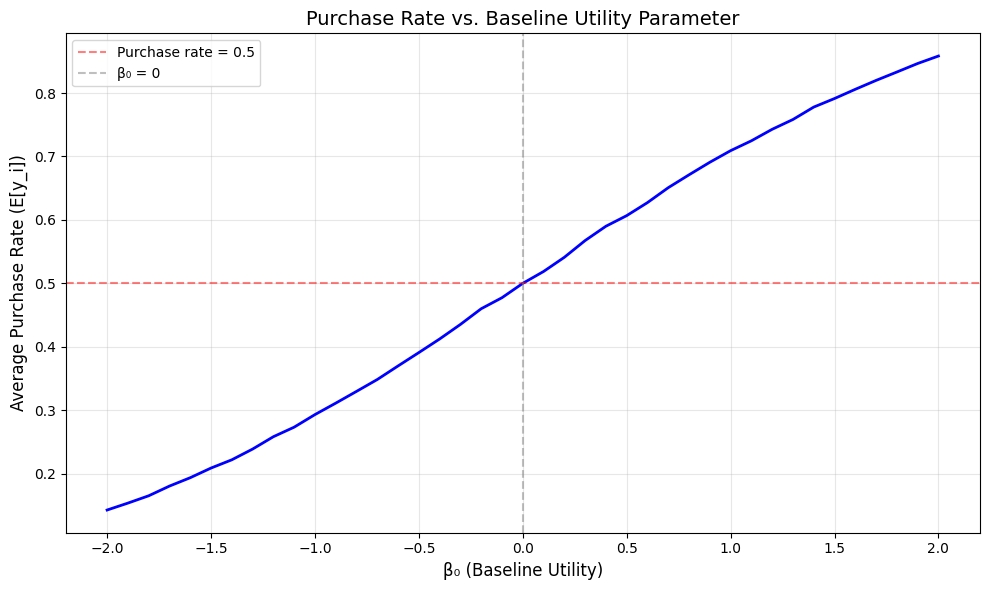

Purchase Rate Analysis
Parameters: α₀ = -1, σ² = 1, N = 100000

Purchase rate when β₀ = -2.0: 0.1427
Purchase rate when β₀ =  0.0: 0.5000
Purchase rate when β₀ =  2.0: 0.8583

β₀ value closest to 50% purchase rate: 0.0


In [75]:
N = 100000

# Vary beta_0 from -2 to 2 in steps of 0.1
beta_0_values = np.arange(-2, 2.1, 0.1)
avg_y = []
results = {}

for beta_0 in beta_0_values:
    Y, D, U = generate_data(N, beta_0)
    avg_y.append(Y.mean())
results[1] = avg_y

plt.figure(figsize=(10, 6))
plot_avg_y(N, avg_y, beta_0_values)

### Part C

In [64]:
def compare_beta_plots(results):
    plt.figure(figsize=(10, 6))
    plt.plot(beta_0_values, results[1.0], 'b-', linewidth=2, label='σ² = 1.0')
    plt.plot(beta_0_values, results[0.1], 'r-', linewidth=2, label='σ² = 0.1')
    plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    plt.xlabel('β₀ (Baseline Utility)', fontsize=12)
    plt.ylabel('Average Purchase Rate', fontsize=12)
    plt.title('Purchase Rate vs. β₀: Effect of Heterogeneity (σ²)', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Compare steepness
    print("=" * 60)
    print("Comparing Steepness")
    print("=" * 60)
    for sigma_sq in [1.0, 0.1]:
        rates = np.array(results[sigma_sq])
        # Find β₀ values where rate crosses 0.25 and 0.75
        idx_25 = np.argmin(np.abs(rates - 0.25))
        idx_75 = np.argmin(np.abs(rates - 0.75))
        range_width = beta_0_values[idx_75] - beta_0_values[idx_25]
        print(f"σ² = {sigma_sq}: β₀ range from 25% to 75% purchase = {range_width:.2f}")

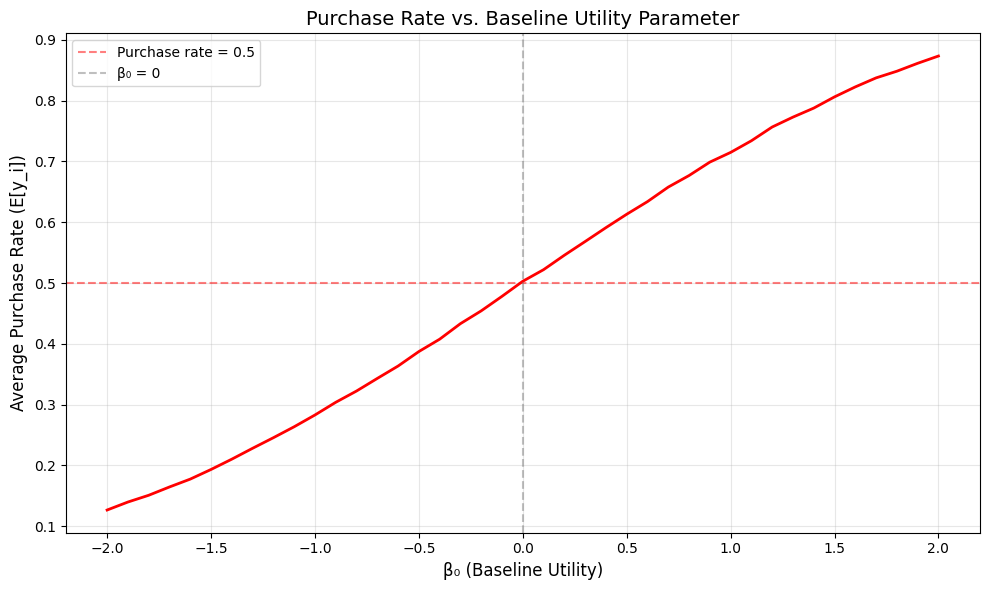

Purchase Rate Analysis
Parameters: α₀ = -1, σ² = 0.1, N = 100000

Purchase rate when β₀ = -2.0: 0.1265
Purchase rate when β₀ =  0.0: 0.5029
Purchase rate when β₀ =  2.0: 0.8735

β₀ value closest to 50% purchase rate: 0.0


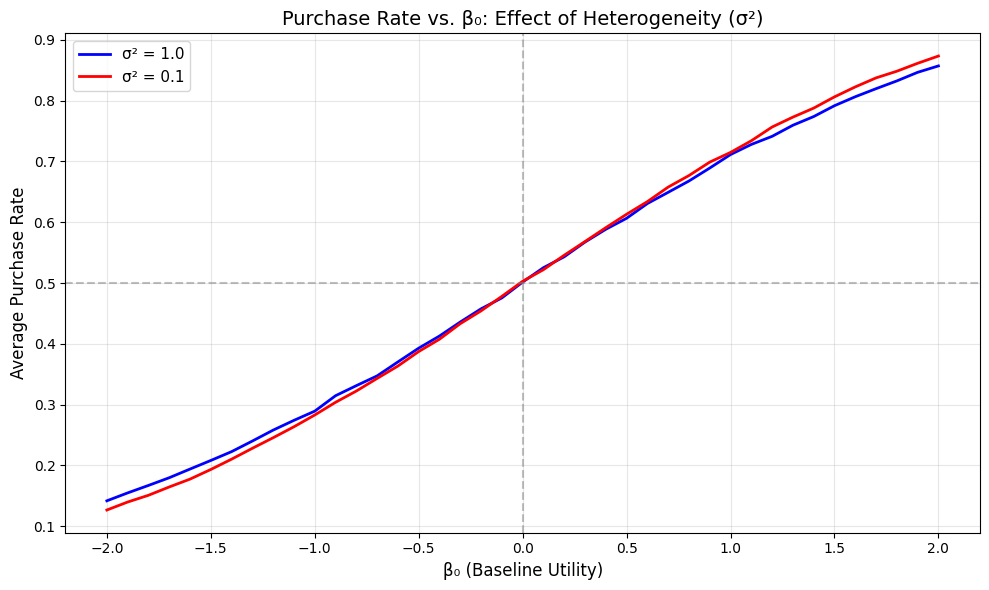

Comparing Steepness
σ² = 1.0: β₀ range from 25% to 75% purchase = 2.40
σ² = 0.1: β₀ range from 25% to 75% purchase = 2.40


In [65]:
N = 100000
sigma_sq =0.1

# Vary beta_0 from -2 to 2 in steps of 0.1
beta_0_values = np.arange(-2, 2.1, 0.1)
avg_y = []

for beta_0 in beta_0_values:
    Y, D, U = generate_data(N=N, beta_0=beta_0, sigma_sq=sigma_sq)
    avg_y.append(Y.mean())
results[sigma_sq] = avg_y

plot_avg_y(N, avg_y, beta_0_values, sigma_sq=sigma_sq, color='r-')
compare_beta_plots(results)

The purchase rate curve is slightly steeper with a lower heterogeneity parameter sigma_sq. This is expected as the purchasing preferences of consumers is more uniformand are thus clumped into tighter data ranges.

### Part D

( α₀ + z_i ) represents the demand-side sensititvity to price changes, assuming that one is for population-based sensitivity and the other is for individual-specific sensitivity.

( β0 + ui ) represent the other intrinsic utility from purchasing the product. β0 is assumed as the average intrinsic utility of the product value (brand, quality, features, reliability), and ui as the other unobserved factors causing short-term utility shocks to the value of the specific product (weather, season, advertising).

### Part E

In [67]:
N = 10000
Y, D, u = generate_data(N, beta_0)
p = D[:, 1]
z = D[:, 2]
pz = p * z

# Construct design matrix
X = np.column_stack([np.ones(N), p, pz])

# Run linear regression
reg = sm.OLS(Y, X).fit()

In [69]:
# Print results
print("=" * 70)
print("Linear Regression: Y ~ 1 + p + p*z")
print("=" * 70)
print(reg.summary())

Linear Regression: Y ~ 1 + p + p*z
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     1320.
Date:                Tue, 18 Nov 2025   Prob (F-statistic):               0.00
Time:                        10:45:13   Log-Likelihood:                -2468.5
No. Observations:               10000   AIC:                             4943.
Df Residuals:                    9997   BIC:                             4965.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.

#### Analysis
The price coefficient (x1) is negative indicating a negative relationship between price and purchase rate. This matches expections through the law of marginal demand, where consumer demand falls as the cost of items rise.

The p*z coefficient (x2) is positive indicating a positive relationship between individual preference and purchase rate. This matches expectations: as z increases, meaning that individual i becomes less price sensitive, the effect of price changes has less of an effect on purchasing rate.

For all coefficients, standard errors are very low coupled with a very large t-statistic. This is a good indication that the coefficient results are statistically significant in the used model with very minimal variance in expected results.

### Part F

In [ ]:
N = 10000
beta_0_values = np.arange(0, 2.1, 0.1)

int_coef = []
p_coef = []
pz_coef = []

for beta_0 in beta_0_values:
    Y, D, u = generate_data(N, beta_0)
    X = np.column_stack([np.ones(N), D[:, 1], D[:, 1] * D[:, 2]])

    coefficients = sm.OLS(Y, X).fit().params

    int_coef.append(coefficients[0])
    p_coef.append(coefficients[1])
    pz_coef.append(coefficients[2])

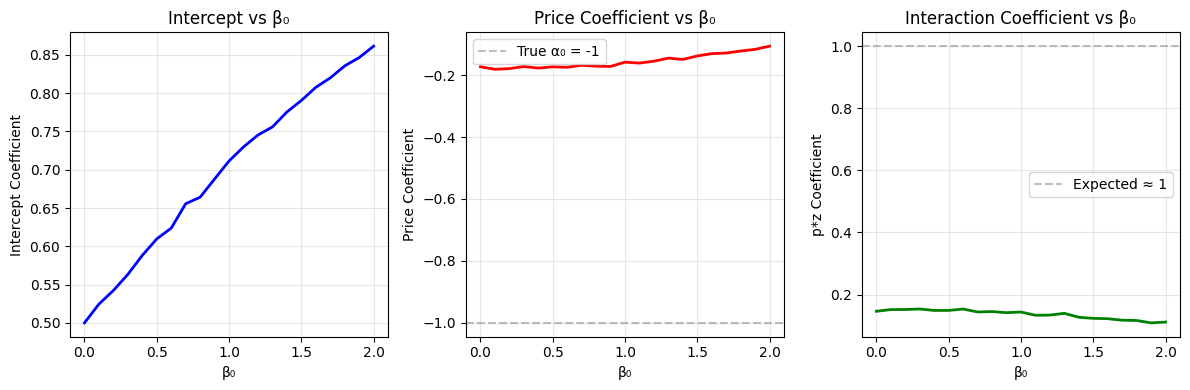

In [77]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(beta_0_values, int_coef, 'b-', linewidth=2)
plt.xlabel('β₀')
plt.ylabel('Intercept Coefficient')
plt.title('Intercept vs β₀')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(beta_0_values, p_coef, 'r-', linewidth=2)
plt.axhline(y=-1, color='gray', linestyle='--', alpha=0.5, label='True α₀ = -1')
plt.xlabel('β₀')
plt.ylabel('Price Coefficient')
plt.title('Price Coefficient vs β₀')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(beta_0_values, pz_coef, 'g-', linewidth=2)
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Expected ≈ 1')
plt.xlabel('β₀')
plt.ylabel('p*z Coefficient')
plt.title('Interaction Coefficient vs β₀')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The intercept coefficient captures the baseline purchase probability when p=0 and pz=0. 

follows a positive linear model as expected considering it models the intrinsic utility of the purchase.

The price coefficient stays relatively flat at around -0.15, then starts to increase after β₀=1. As β₀ increases, the intrisic value of the purchase increases through demand, thus increasing price elasticity. This value, however, differs significantly from the true price coefficient of α=-1. This is due to the fact that the calculated coefficient model is calculated as a linear OLS function